# Project: Credit Card Fraud Detection

In [2]:
# importing the linear algebra library
import numpy as np
# importing data processing library
import pandas as pd
# ignoring the warnings that might be generated
import warnings 
warnings.filterwarnings("ignore")
# importing the pyplot library from the matplotlib
#import matplotlib.pyplot as plt
from matplotlib import pyplot as plt

In [3]:
df = pd.read_csv('creditcard.csv')
#df

# Data Cleaning

In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


**we see that the last column "class" is the categorical variable and all the other columns are either one of Time, "Amount" or the components that have come after PCA(Principal Component Analysis)**

In [7]:
# display all the columns
pd.options.display.max_columns = None
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,-0.915427,-1.040458,-0.031513,-0.188093,-0.084316,0.041333,-0.302620,-0.660377,0.167430,-0.256117,0.382948,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [14]:
df.shape

(284807, 31)

In [16]:
print("Number of Columns: {}".format(df.shape[1]))
print("Number of Rows: {}".format(df.shape[0]))

Number of Columns: 31
Number of Rows: 284807


**we can see that the data consists of 284807 rows and 31 columns**

In [19]:
# to check if there are any NULL values and the data type of all the columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

**we see that there no NULL values present in the data**

In [22]:
# checking missing values in each columns
# pd.isnull(df)
df.isnull()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
284803,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
284804,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
284805,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [24]:
# checking missing values in each columns
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [26]:
df.shape

(284807, 31)

In [28]:
df['V1'].describe()

count    2.848070e+05
mean     1.168375e-15
std      1.958696e+00
min     -5.640751e+01
25%     -9.203734e-01
50%      1.810880e-02
75%      1.315642e+00
max      2.454930e+00
Name: V1, dtype: float64

In [30]:
df['V7'].describe()

count    2.848070e+05
mean    -5.556467e-16
std      1.237094e+00
min     -4.355724e+01
25%     -5.540759e-01
50%      4.010308e-02
75%      5.704361e-01
max      1.205895e+02
Name: V7, dtype: float64

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

**there were 284807 rows before the remove duplicates and null values**

In [35]:
# if null values available
df.dropna(inplace = True)

In [37]:
# checking duplicate data in dataset
df.duplicated().any()

True

In [38]:
# remove duplicate data from dataset
# df = df.drop_duplicates()
df.drop_duplicates(inplace = True)

In [39]:
df.shape

(283726, 31)

**we can see that the unnecessary data have been dropped and remove, now the number of rows is 283726**

In [44]:
# distribution of valid transactions and invalid/fraud transactions
df['Class'].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

#### 👆This Data is highly unblanced
0 --> Valid Transactions

1 --> Invalid/Fraud Transactions

In [47]:
initialDistribution = df['Class']
import collections
collections.Counter(initialDistribution)

Counter({0: 283253, 1: 473})

**we see that there are 283253 valid transactions present and 473 frauds/invalid transactions**

In [50]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,-0.001441,0.000202,-0.000715,0.000603,0.000252,0.001043,0.001162,0.000170,0.001515,-0.000264,0.000187,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,1.076407,1.018720,0.994674,0.995430,0.952215,0.914894,0.873696,0.842507,0.837378,0.813379,0.769984,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,-24.588262,-4.797473,-18.683715,-5.791881,-19.214325,-4.498945,-14.129855,-25.162799,-9.498746,-7.213527,-54.497720,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,-0.535578,-0.761649,-0.406198,-0.647862,-0.425732,-0.581452,-0.466860,-0.483928,-0.498014,-0.456289,-0.211469,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,-0.093237,-0.032306,0.139072,-0.012927,0.050209,0.049299,0.067119,-0.065867,-0.002142,0.003367,-0.062353,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,0.453619,0.739579,0.616976,0.663178,0.492336,0.650104,0.523512,0.398972,0.501956,0.458508,0.133207,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,23.745136,12.018913,7.848392,7.126883,10.526766,8.877742,17.315112,9.253526,5.041069,5.591971,39.420904,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


# EDA
## Exploratory Data Analysis

In [53]:
import seaborn as sns

Text(0.5, 1.0, 'correlation_matrix_initial')

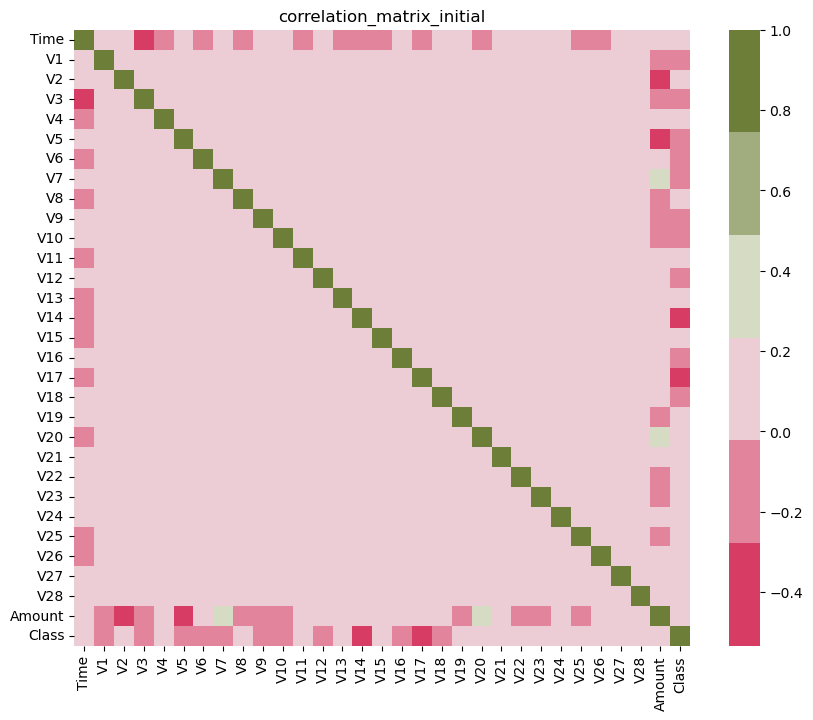

In [54]:
f, ax = plt.subplots(figsize = (10, 8))
corr = df.corr()
sns.heatmap(corr, mask = np.zeros_like(corr, dtype = np.bool_), cmap = sns.diverging_palette(2, 100), square = True, ax = ax)
plt.savefig('Figures/correlation_matrix_initial.jpg')
plt.title('correlation_matrix_initial')

**On generating a heatmap from the seaborn library we see that columns - ‘V1’, ’V3’, ’V5’, ’V6’, ’V7’, ’V9’ ,’V10’, ‘V12’, ‘V14’, ‘V16’, ‘V17’, ‘V18’ have a relatively high correlation with the class column.**

In [57]:
seeCorr = df.corr().Class
seeCorr = abs(seeCorr)
seeCorr = seeCorr.sort_values()

In [58]:
seeCorr

V25       0.003202
V15       0.003300
V13       0.003897
V26       0.004265
V22       0.004887
Amount    0.005777
V23       0.006333
V24       0.007210
V28       0.009682
Time      0.012359
V20       0.021486
V27       0.021892
V21       0.026357
V8        0.033068
V19       0.033631
V6        0.043915
V2        0.084624
V5        0.087812
V9        0.094021
V1        0.094486
V18       0.105340
V4        0.129326
V11       0.149067
V7        0.172347
V3        0.182322
V16       0.187186
V10       0.206971
V12       0.250711
V14       0.293375
V17       0.313498
Class     1.000000
Name: Class, dtype: float64

**We also see that columns 'V28', 'V24' ,'V23', 'V22', 'V26', 'V13', 'V15', 'V25', 'Amount' had a correlation of less than 0.01 with the class column.**

Text(0.5, 1.0, 'histogram_V17')

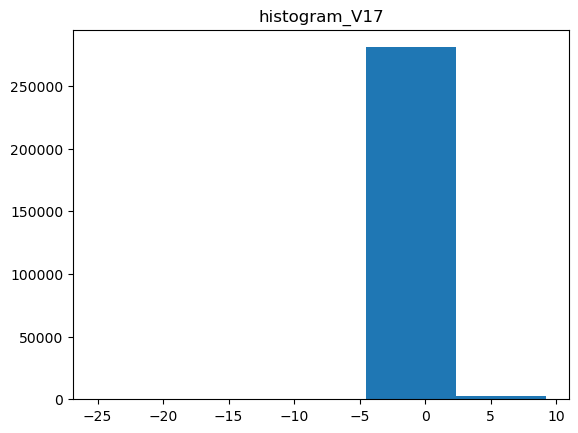

In [63]:
#histogram of the most correlated column
plt.hist(df['V17'], bins=5)
plt.savefig('Figures/histogram_V17.jpg')
plt.title('histogram_V17')

Text(0.5, 1.0, 'histogram_V14')

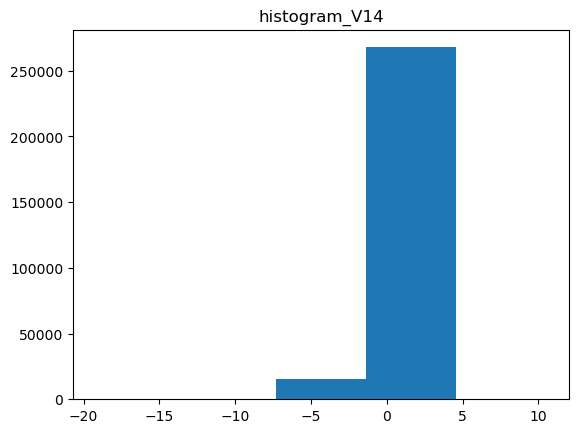

In [65]:
#histogram of the second most correlated column
plt.hist(df['V14'], bins=5)
plt.savefig('Figures/histogram_V14.jpg')
plt.title('histogram_V14')

Text(0.5, 1.0, 'histogram_V25')

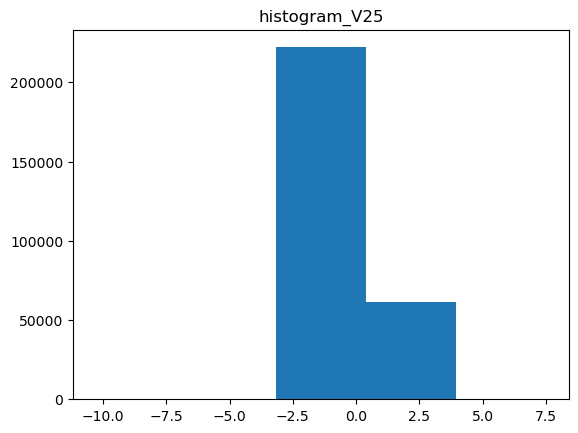

In [67]:
#histogram of the Least correlated column
plt.hist(df['V25'], bins=5)
plt.savefig('Figures/histogram_V25.jpg')
plt.title('histogram_V25')

In [69]:
df.drop(['V28','V24','V23','V22','V26','V13','V15','V25','Amount'],axis = 1).head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V14,V16,V17,V18,V19,V20,V21,V27,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.311169,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.133558,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,-0.143772,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.008983,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,-0.165946,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,-0.055353,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,-0.287924,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.062723,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,-1.119670,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.219422,0


**The columns which had less correlation with the data were dropped**

In [72]:
dfCrr = df.drop(['V28','V24','V23','V22','V26','V13','V15','V25','Amount'],axis=1)

**The data was then stored in dfCrr after dropping the columns**

In [75]:
dfCrr.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V14,V16,V17,V18,V19,V20,V21,V27,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.311169,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.133558,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,-0.143772,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.008983,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,-0.165946,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,-0.055353,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,-0.287924,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.062723,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,-1.119670,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.219422,0


In [77]:
#info of the dfCrr DataFrame
dfCrr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 283726 entries, 0 to 284806
Data columns (total 22 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283726 non-null  float64
 1   V1      283726 non-null  float64
 2   V2      283726 non-null  float64
 3   V3      283726 non-null  float64
 4   V4      283726 non-null  float64
 5   V5      283726 non-null  float64
 6   V6      283726 non-null  float64
 7   V7      283726 non-null  float64
 8   V8      283726 non-null  float64
 9   V9      283726 non-null  float64
 10  V10     283726 non-null  float64
 11  V11     283726 non-null  float64
 12  V12     283726 non-null  float64
 13  V14     283726 non-null  float64
 14  V16     283726 non-null  float64
 15  V17     283726 non-null  float64
 16  V18     283726 non-null  float64
 17  V19     283726 non-null  float64
 18  V20     283726 non-null  float64
 19  V21     283726 non-null  float64
 20  V27     283726 non-null  float64
 21  Class   283726 

Text(0.5, 1.0, 'correlation_matrix_final')

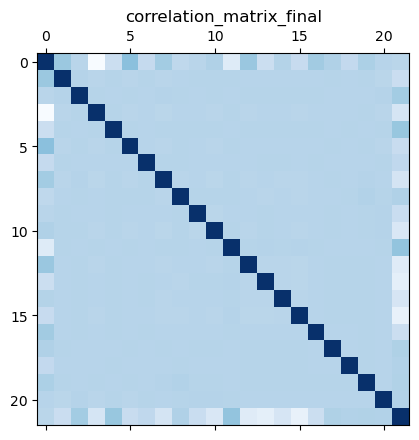

In [79]:
# correlation plot of the dfCrr dataframe
plt.matshow(dfCrr.corr(), cmap = 'Blues')
plt.savefig('Figures/correlation_matrix_final.jpg')
plt.title('correlation_matrix_final')

In [81]:
# dropping Class column
dfCrr.drop(['Class'], axis=1).head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V14,V16,V17,V18,V19,V20,V21,V27
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.311169,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.133558
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,-0.143772,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.008983
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,-0.165946,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,-0.055353
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,-0.287924,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.062723
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,-1.119670,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.219422


In [83]:
dfWithoutClass = dfCrr.drop(['Class'],axis=1)
dfWithoutClass.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V14,V16,V17,V18,V19,V20,V21,V27
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.311169,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.133558
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,-0.143772,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.008983
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,-0.165946,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,-0.055353
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,-0.287924,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.062723
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,-1.119670,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.219422


**dfWithoutClass is the DataFrame without the class we use this DataFrame to make our clusters**

In [86]:
classes = dfCrr['Class']
classes.head()

0    0
1    0
2    0
3    0
4    0
Name: Class, dtype: int64

**classes is a DataSeries of the classes which we will drop**

In [89]:
dfWithoutClass.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V14,V16,V17,V18,V19,V20,V21,V27
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,-0.001441,0.000202,-0.000715,0.000252,0.001162,0.000170,0.001515,-0.000264,0.000187,-0.000371,0.001763
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,1.076407,1.018720,0.994674,0.952215,0.873696,0.842507,0.837378,0.813379,0.769984,0.723909,0.395744
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,-24.588262,-4.797473,-18.683715,-19.214325,-14.129855,-25.162799,-9.498746,-7.213527,-54.497720,-34.830382,-22.565679
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,-0.535578,-0.761649,-0.406198,-0.425732,-0.466860,-0.483928,-0.498014,-0.456289,-0.211469,-0.228305,-0.070641
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,-0.093237,-0.032306,0.139072,0.050209,0.067119,-0.065867,-0.002142,0.003367,-0.062353,-0.029441,0.001479
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,0.453619,0.739579,0.616976,0.492336,0.523512,0.398972,0.501956,0.458508,0.133207,0.186194,0.091208
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,23.745136,12.018913,7.848392,10.526766,17.315112,9.253526,5.041069,5.591971,39.420904,27.202839,31.612198


# Data Normalization
## We normalize the data using the MinMaxScaler

In [92]:
from sklearn import preprocessing

In [94]:
min_max_scaler = preprocessing.MinMaxScaler()
np_scaled = min_max_scaler.fit_transform(dfWithoutClass)
dfN = pd.DataFrame(np_scaled)
dfN.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
0,0.000000,0.935192,0.766490,0.881365,0.313023,0.763439,0.267669,0.266815,0.786444,0.475312,0.510600,0.252484,0.680908,0.635591,0.434392,0.737173,0.655066,0.594863,0.582942,0.561184,0.418976
1,0.000000,0.978542,0.770067,0.840298,0.271796,0.766120,0.262192,0.264875,0.786298,0.453981,0.505267,0.381188,0.744342,0.641219,0.464105,0.727794,0.640681,0.551930,0.579530,0.557840,0.416345
2,0.000006,0.935217,0.753118,0.868141,0.268766,0.762329,0.281122,0.270177,0.788042,0.410603,0.513018,0.322422,0.706683,0.640473,0.357443,0.763381,0.644945,0.386683,0.585855,0.565477,0.415489
3,0.000006,0.941878,0.765304,0.868484,0.213661,0.765647,0.275559,0.266803,0.789434,0.414999,0.507585,0.271817,0.710910,0.636372,0.415653,0.711253,0.788492,0.467058,0.578050,0.559734,0.417669
4,0.000012,0.938617,0.776520,0.864251,0.269796,0.762975,0.263984,0.268968,0.782484,0.490950,0.524303,0.236355,0.724477,0.608406,0.434995,0.724243,0.650665,0.626060,0.584615,0.561327,0.420561


**dfN is the data after normalization**
# K-Means Clusterring
#### We run the elbow method to see which is the best number of clusters that we should form

In [97]:
from sklearn.cluster import KMeans

In [98]:
wcss = [] # Within-Cluster Sum of Squares
for i in range(1,5):
    kmeans = KMeans(n_clusters=i, init = 'k-means++', random_state = 0)
    kmeans.fit(dfN)
    wcss.append(kmeans.inertia_)

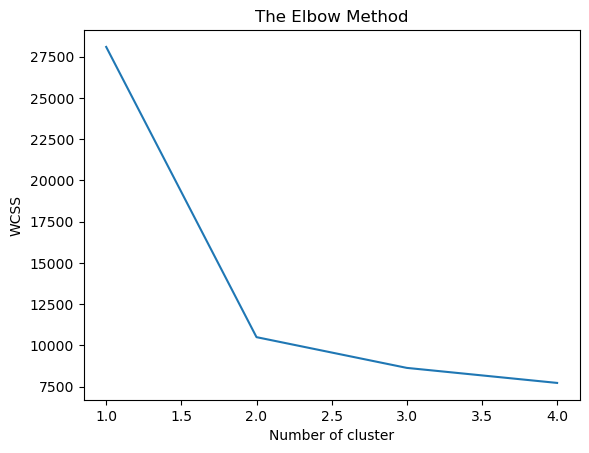

In [99]:
plt.plot(range(1,5),wcss)
plt.savefig('Figures/Elbow_Method.jpg')
plt.title('The Elbow Method')
plt.xlabel('Number of cluster')
plt.ylabel('WCSS')
plt.show()

**The apt number of clusters seem to be two**

**We run k-means++ with n_clusters specified as 2**

In [102]:
kmeans = KMeans(n_clusters = 2, init = 'k-means++', random_state = 0)
y2_kmeans = kmeans.fit_predict(dfN)

In [103]:
y2_kmeans

array([1, 1, 1, ..., 0, 0, 0])

**y2_kmeans is the result of Kmeans on the normalized data**

In [105]:
collections.Counter(y2_kmeans)

Counter({1: 152713, 0: 131013})

**Now, We assume that the cluster with more data points is the non fraudlent data set**

In [112]:
if collections.Counter(y2_kmeans) [1] > collections.Counter(y2_kmeans) [0]:
    y2_kmeans = np.subtract(1, y2_kmeans)
collections.Counter(y2_kmeans)

Counter({0: 152713, 1: 131013})

**Now, We calculate the mean square error for the K-Means**

In [115]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(initialDistribution, y2_kmeans)
mse # mean square error

0.46239681946666855

**Now, We calculate the root mean square error for K-Means**

In [118]:
from math import sqrt
rms = sqrt(mean_squared_error(initialDistribution, y2_kmeans))
rms # root mean square

0.6799976613685289

**Now, We calculate the accuracy for K-Means**

In [121]:
# data is the actual value and label is the predicted value
def accuracy(df, label):
    true = 0
    false = 0
    assert len(df) == len(label)
    for i in range(len(df)):
        if df[i] == label[i]:
            true = true + 1
        else:
            false = false + 1
    val = float(true) / float(true + false)
    
    return val * 100

In [123]:
type(classes.values)

numpy.ndarray

In [125]:
type(y2_kmeans)

numpy.ndarray

In [127]:
accuracy(classes.values, y2_kmeans)

53.760318053333144

**Now, We calculate the recall for K-Means**

In [130]:
# data is the actual value and lable is the predicted value
def recall(df, label):
    true_positive = 0
    false_negative = 0
    assert len(df) == len(label)
    for i in range(len(df)):
        if df[i] == label[i] and df[i] == 1:
            true_positive = true_positive + 1
        elif df[i] == 1 and label[i] == 0:
            false_negative = false_negative + 1
        i = i + 1
    val = float(true_positive) / float(true_positive + false_negative)

    return val * 100

In [132]:
recall(classes.values, y2_kmeans)

30.866807610993657

**Now, We calculate the precision for K-Means**

In [135]:
# data is the actual value and label is the predicted value
def precision(df, label):
    true_positive = 0
    false_positive = 0
    assert len(df) == len(label)
    for i in range(len(df)):
        if df[i] == label[i] and df[i] == 1:
            true_positive = true_positive + 1
        elif df[i] == 0 and label[i] == 1:
            false_positive = false_positive + 1
    val = float(true_positive) / float(true_positive + false_positive)

    return val * 100

In [137]:
precision(classes.values, y2_kmeans)

0.11143932281529315

**Now, We calculate the correlation between the predicted and the actual values**

In [140]:
np.corrcoef(classes.values, y2_kmeans)

array([[ 1.        , -0.01254863],
       [-0.01254863,  1.        ]])

In [142]:
from scipy.stats.stats import pearsonr
pearsonr(classes.values, y2_kmeans)

PearsonRResult(statistic=-0.012548631039575674, pvalue=2.3190503448913864e-11)

# Principle Component Analysis (PCA)

In [145]:
from sklearn.decomposition import PCA

In [147]:
# we calculate the two main principle components
pca = PCA(n_components = 2)
principalComponents = pca.fit_transform(dfN)
principal_df = pd.DataFrame(data = principalComponents, columns = ['principal component 1', 'principal component 2'])
principal_df.head()

,principal component 1,principal component 2
0,-0.548748,0.035054
1,-0.552208,-0.004961
2,-0.552592,-0.172197
3,-0.544321,-0.097107
4,-0.544669,0.063663


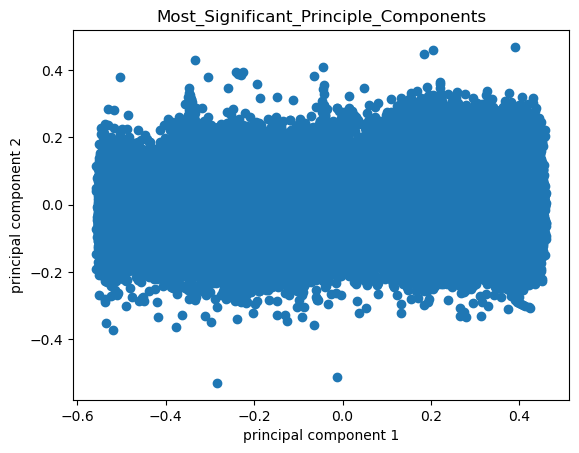

In [149]:
plt.scatter(principal_df.iloc[:,0:1], principal_df.iloc[:,1:2])
plt.xlabel(principal_df.columns.values[0])
plt.ylabel(principal_df.columns.values[1])
plt.savefig('Figures/Most_Significant_Principle_Components.jpg')
plt.title('Most_Significant_Principle_Components')
plt.show()

**The data appears to be quite Density based. There seems to be a huge cluster and all the points far away from these clusters seem to be anomalies. Here we infer that Density based clustering should be the most appropriate for this dataset. However the dataset appears to be huge and DBSCAN does not run on the dataset as the kernel dies quickly.**

In [151]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import joblib

df = pd.read_csv("creditcard.csv")

X = df.drop("Class", axis=1)
y = df["Class"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

# Save
joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

### I deployed a real-time fraud detection system with an interactive dashboard, batch prediction capability, and scalable cloud hosting.